In [6]:
# === Alzheimer's Stage Classification with EfficientNetV2-S ===

import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.manifold import TSNE
from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_v2_s

# ===============================
# Configuration
# ===============================
TEST_PATH = "OD"  # Each folder: 'MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented'
DATA_PATH = "AGD"
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 4
DEVICE = torch.device("cpu" if torch.cuda.is_available() else "cpu")

# ===============================
# Dataset Loader
# ===============================
class AlzheimerMRIDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.filepaths)
    
    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label

# ===============================
# Load & Split Dataset
# ===============================
def load_data():
    class_map = {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}
    filepaths, labels = [], []

    for cls, label in class_map.items():
        class_dir = os.path.join(DATA_PATH, cls)
        for fname in os.listdir(class_dir):
            if fname.endswith('.jpg'):
                filepaths.append(os.path.join(class_dir, fname))
                labels.append(label)

    # Initial stratified split: 70% train, 30% temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        filepaths, labels, test_size=0.30, stratify=labels, random_state=42
    )

    # Then split temp into 1/3 validation (10%) and 2/3 test (20%)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [7]:
# ===============================
# CNN Model - EfficientNetV2-S
# ===============================
def build_cnn():
    model = efficientnet_v2_s(weights="DEFAULT")
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    return model.to(DEVICE)

# ===============================
# Train CNN
# ===============================
def train_cnn(model, train_loader, val_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # ---- TRAIN ----
        model.train()
        correct, total, running_loss = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(correct / total)

        # ---- VALIDATION ----
        model.eval()
        correct, total, val_loss = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Acc: {train_accs[-1]:.4f} | "
              f"Val Acc: {val_accs[-1]:.4f}")

    return model, train_losses, val_losses, train_accs, val_accs

In [8]:
# ===============================
# Feature Extraction
# ===============================
def extract_features(model, dataloader):
    model.eval()
    features, targets = [], []

    feature_extractor = nn.Sequential(
        model.features,
        model.avgpool,
        nn.Flatten(1)
    ).to(DEVICE)

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(DEVICE)
            feats = feature_extractor(images)
            features.append(feats.cpu().numpy())
            targets.extend(labels.numpy())

    return np.vstack(features), np.array(targets)


# ===============================
# Feature Selection & Classifier
# ===============================
def classify_with_xgboost(X_train, y_train, X_test, y_test):
    svd = TruncatedSVD(n_components=100)
    X_train_reduced = svd.fit_transform(X_train)
    X_test_reduced = svd.transform(X_test)

    clf = XGBClassifier( eval_metric='mlogloss')
    clf.fit(X_train_reduced, y_train)

    preds = clf.predict(X_test_reduced)
    print(classification_report(y_test, preds, target_names=['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']))

    return y_test, preds, clf.predict_proba(X_test_reduced)

# ===============================
# Visualizations
# ===============================
def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(val_accs, label="Validation Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title("Loss Curve")
    plt.legend()

    plt.show()

def plot_confusion(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["MD", "MOD", "ND", "VMD"], yticklabels=["MD", "MOD", "ND", "VMD"])
    plt.title("Confusion Matrix")
    plt.show()

def plot_roc(y_true, y_probs):
    y_true_bin = label_binarize(y_true, classes=[0,1,2,3])
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc(fpr, tpr):.2f})")
    plt.legend(); plt.title("ROC Curves"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.show()

def plot_kde(probs):
    for i in range(NUM_CLASSES):
        sns.kdeplot(probs[:, i], label=f'Class {i}')
    plt.title("KDE Plot of Prediction Probabilities")
    plt.legend(); plt.show()

def plot_tsne(X, y):
    tsne = TSNE(n_components=2, perplexity=30)
    X_emb = tsne.fit_transform(X)
    plt.figure(figsize=(8,6))
    for i in range(NUM_CLASSES):
        plt.scatter(X_emb[y == i, 0], X_emb[y == i, 1], label=f'Class {i}', s=10)
    plt.title("t-SNE Projection of Features")
    plt.legend(); plt.show()

In [9]:
def test_single_images(model, transform):
    class_map = {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}
    inv_map = {v:k for k,v in class_map.items()}

    model.eval()

    for cls in class_map.keys():
        cls_dir = os.path.join(TEST_PATH, cls)
        img_name = os.listdir(cls_dir)[0]
        img_path = os.path.join(cls_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(input_tensor)
            prob = torch.softmax(output, dim=1)
            pred = torch.argmax(prob).item()

        plt.imshow(image)
        plt.axis("off")
        plt.title(f"True: {cls} | Predicted: {inv_map[pred]}\n"
                  f"Confidence: {prob[0][pred]:.2f}")
        plt.show()

Training EfficientNetV2-S CNN...
Epoch 1/10 | Train Acc: 0.6122 | Val Acc: 0.7464
Epoch 2/10 | Train Acc: 0.8271 | Val Acc: 0.8238
Epoch 3/10 | Train Acc: 0.9312 | Val Acc: 0.8639
Epoch 4/10 | Train Acc: 0.9685 | Val Acc: 0.8754
Epoch 5/10 | Train Acc: 0.9730 | Val Acc: 0.8940
Epoch 6/10 | Train Acc: 0.9840 | Val Acc: 0.8954
Epoch 7/10 | Train Acc: 0.9855 | Val Acc: 0.9040
Epoch 8/10 | Train Acc: 0.9892 | Val Acc: 0.9140
Epoch 9/10 | Train Acc: 0.9869 | Val Acc: 0.8940
Epoch 10/10 | Train Acc: 0.9894 | Val Acc: 0.9112


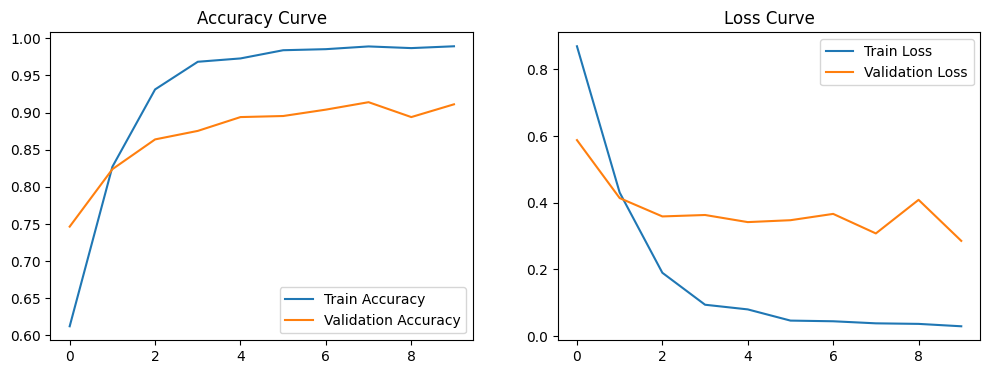

Extracting deep features...
Training XGBoost classifier...
                  precision    recall  f1-score   support

    MildDemented       0.93      0.97      0.95       392
ModerateDemented       1.00      1.00      1.00       292
     NonDemented       0.89      0.87      0.88       320
VeryMildDemented       0.89      0.87      0.88       392

        accuracy                           0.93      1396
       macro avg       0.93      0.93      0.93      1396
    weighted avg       0.92      0.93      0.93      1396



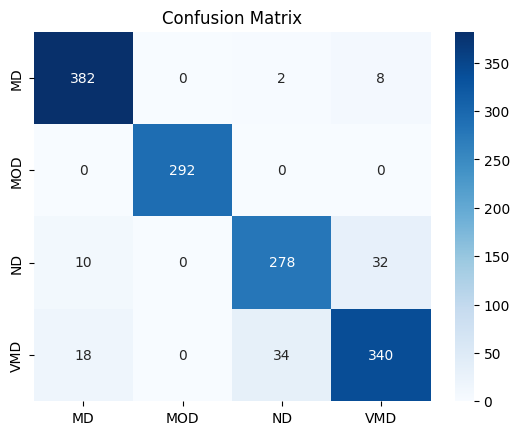

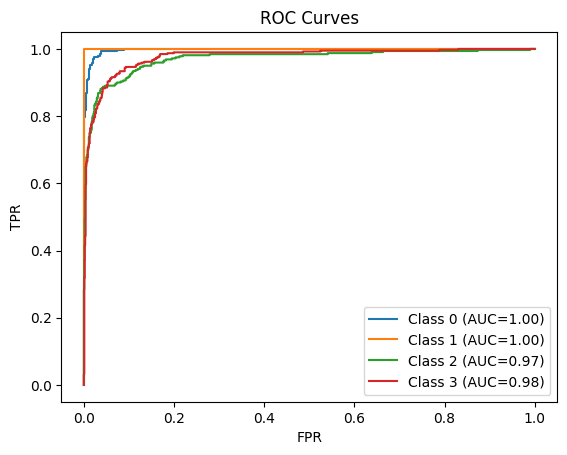

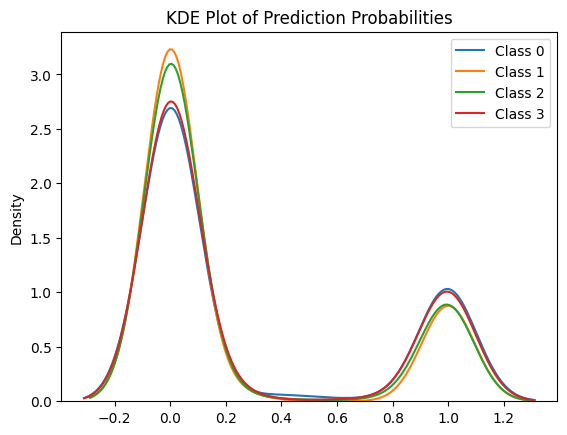

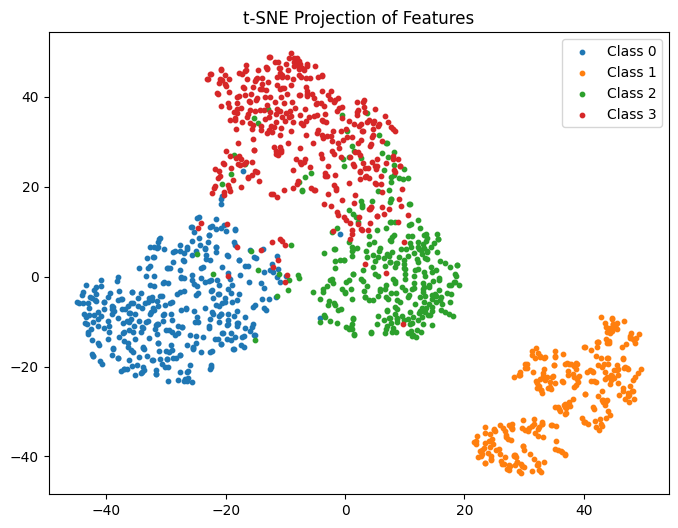

Testing single images from each class...


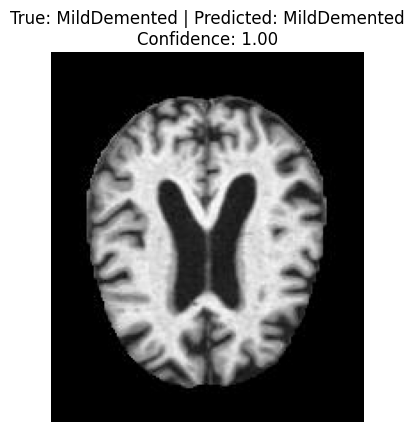

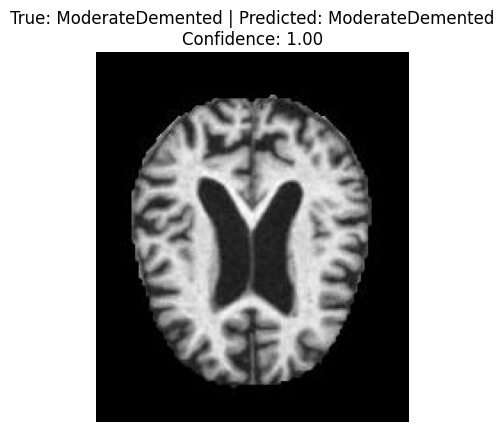

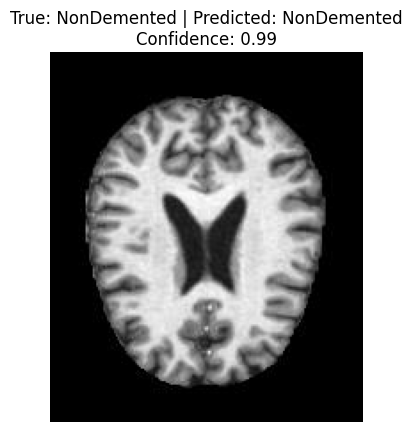

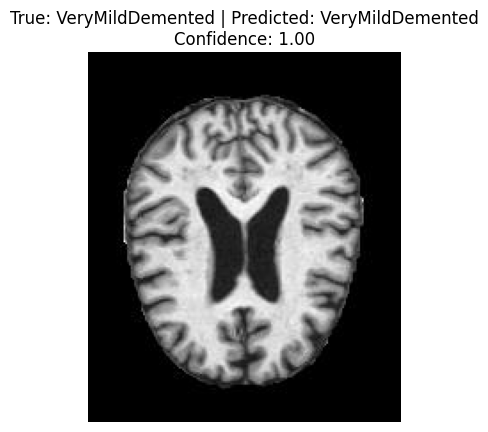

In [10]:
def main():
    train_files, val_files, test_files, train_labels, val_labels, test_labels = load_data()

    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    train_loader = DataLoader(AlzheimerMRIDataset(train_files, train_labels, transform),
                              batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(AlzheimerMRIDataset(val_files, val_labels, transform),
                            batch_size=BATCH_SIZE)
    test_loader = DataLoader(AlzheimerMRIDataset(test_files, test_labels, transform),
                             batch_size=BATCH_SIZE)

    print("Training EfficientNetV2-S CNN...")
    model = build_cnn()
    model, tr_loss, val_loss, tr_acc, val_acc = train_cnn(
        model, train_loader, val_loader, epochs=10
    )

    plot_training_curves(tr_loss, val_loss, tr_acc, val_acc)

    print("Extracting deep features...")
    X_train, y_train = extract_features(model, train_loader)
    X_test, y_test = extract_features(model, test_loader)

    print("Training XGBoost classifier...")
    y_true, y_pred, probs = classify_with_xgboost(X_train, y_train, X_test, y_test)

    plot_confusion(y_true, y_pred)
    plot_roc(y_true, probs)
    plot_kde(probs)
    plot_tsne(X_test, y_test)

    print("Testing single images from each class...")
    test_single_images(model, transform)

if __name__ == "__main__":
    main()